In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  T

In [3]:
# Identify missing values for Task 2
missing_data = df.isnull().sum()
print("--- Missing Values per Column ---")
print(missing_data[missing_data > 0])

--- Missing Values per Column ---
Series([], dtype: int64)


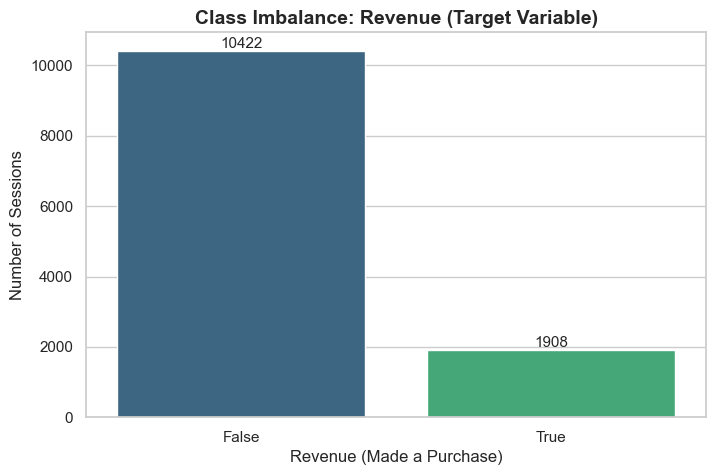

In [4]:
# Plot the target variable to show class imbalance
plt.figure(figsize=(8, 5))

ax = sns.countplot(x='Revenue', data=df, hue='Revenue', palette='viridis', legend=False)

plt.title('Class Imbalance: Revenue (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (Made a Purchase)', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.show()

In [5]:
import pandas as pd

# 1. Load data original
df = pd.read_csv('online_shoppers_intention.csv')

# 2. Basic Cleaning (Buang baris yang sebiji sama)
df = df.drop_duplicates()

# 3. Handle Binary/Boolean columns (True/False -> 1/0)
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# 4. One-Hot Encoding  
categorical_cols = ['VisitorType', 'Month', 'OperatingSystems', 'Region', 'TrafficType', 'Browser']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 5. Export Data (tak scaling)
df.to_csv('preprocessed_shoppers.csv', index=False)

print("Data cleaning & encoding complete! Final shape:", df.shape)
df.head()

Data cleaning & encoding complete! Final shape: (12205, 69)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
def run_stratified_pipeline(X, y, model_obj, model_name):
    """
    Creates a pipeline, runs Stratified K-Fold CV, and returns average metrics.
    Ensures scaling is fitted only on training folds.
    """
    # 1. Define the CV strategy (5-fold is standard for this dataset size)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 2. Build the Pipeline: Scaler -> Model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model_obj)
    ])

    # 3. Define metrics (Focusing on F1 and Recall for imbalanced Revenue data)
    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

    # 4. Run Cross-Validation
    cv_results = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

    # 5. Calculate means
    output = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}
    print(f"\nResults for {model_name}:")
    for m, val in output.items():
        print(f"  {m.capitalize()}: {val:.4f}")
    return output


df = pd.read_csv('preprocessed_shoppers.csv')
X = df.drop('Revenue', axis=1)
y = df['Revenue']